<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/QFT2004e.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

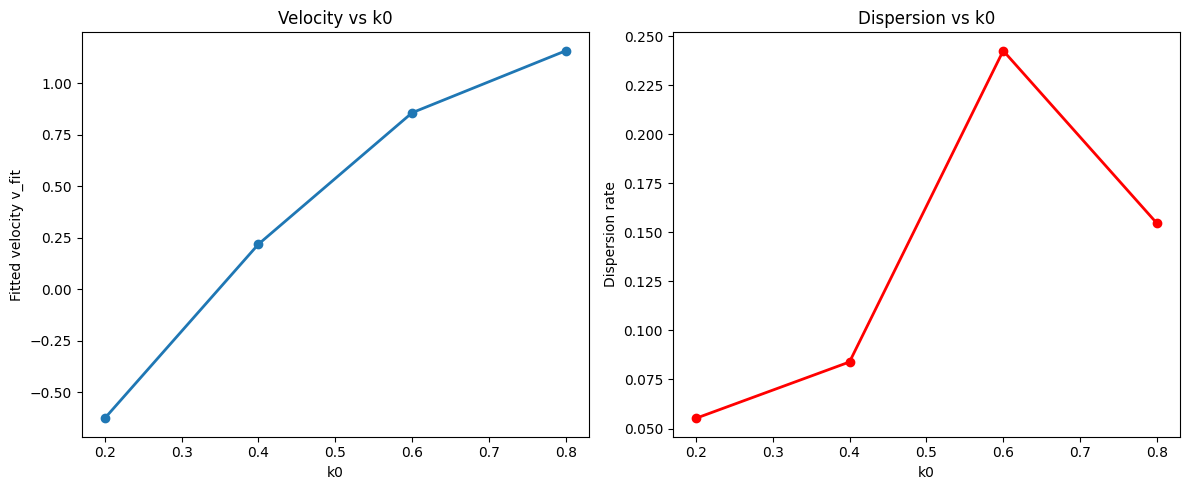

k0 values:         [0.2, 0.4, 0.6, 0.8]
v_fit values:      [np.float64(-0.6268056701417442), np.float64(0.21822545563635645), np.float64(0.8562664066601751), np.float64(1.1570539263481951)]
dispersion rates:  [np.float64(0.05520242496533732), np.float64(0.08393005278190255), np.float64(0.24254261956354126), np.float64(0.15458025397072966)]


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft, ifft, fftfreq

# ============================================================
# QFT2004e — Velocity–Dispersion Mapping
# ============================================================

# -----------------------------
# Lattice and time parameters
# -----------------------------
N = 1024
dx = 1.0
x = np.arange(N) * dx
dk = 2*np.pi/(N*dx)
k = fftfreq(N, d=dx) * 2*np.pi

dt = 0.05
steps = 800

# -----------------------------
# Dispersion relation ω(k)
# -----------------------------
c = 1.0
m = 0.5
omega = np.sqrt(c**2 * k**2 + m**2)

# -----------------------------
# Sweep parameters
# -----------------------------
k0_list = [0.2, 0.4, 0.6, 0.8]
sigma_x = 4.0

v_fits = []
disp_rates = []

# ============================================================
# Helper: build positive-frequency Gaussian packet
# ============================================================
def make_packet(k0):
    psi0 = np.exp(-0.5*((x - N*dx/2)/sigma_x)**2) * np.cos(k0 * (x - N*dx/2))
    Psi0 = fft(psi0)
    Psi0[k < 0] = 0.0
    psi0 = np.real(ifft(Psi0))
    return psi0, Psi0

# ============================================================
# Main sweep
# ============================================================
for k0 in k0_list:
    psi, Psi = make_packet(k0)

    # Storage for diagnostics
    x_peak = []
    width = []

    # Initial peak location
    peak0 = np.argmax(psi)

    # Time evolution
    for n in range(steps):
        # Evolve in k-space
        Psi = Psi * np.exp(-1j * omega * dt)
        psi = np.real(ifft(Psi))

        # Diagnostics
        peak = np.argmax(psi)
        x_peak.append(peak)

        # Width (second moment around peak)
        dx_arr = (np.arange(N) - peak)
        width.append(np.sqrt(np.sum(dx_arr**2 * psi**2) / np.sum(psi**2)))

    # Convert to arrays
    x_peak = np.array(x_peak)
    width = np.array(width)

    # Fit early-time velocity
    t = np.arange(steps) * dt
    fit_mask = t < (steps*dt*0.25)
    coeff = np.polyfit(t[fit_mask], x_peak[fit_mask], 1)
    v_fit = coeff[0]

    # Fit dispersion rate (linear fit to width)
    coeff_w = np.polyfit(t[fit_mask], width[fit_mask], 1)
    disp_rate = coeff_w[0]

    v_fits.append(v_fit)
    disp_rates.append(disp_rate)

# ============================================================
# Plot results
# ============================================================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(k0_list, v_fits, 'o-', lw=2)
plt.xlabel("k0")
plt.ylabel("Fitted velocity v_fit")
plt.title("Velocity vs k0")

plt.subplot(1,2,2)
plt.plot(k0_list, disp_rates, 'o-', lw=2, color='red')
plt.xlabel("k0")
plt.ylabel("Dispersion rate")
plt.title("Dispersion vs k0")

plt.tight_layout()
plt.show()

# Print numerical results
print("k0 values:        ", k0_list)
print("v_fit values:     ", v_fits)
print("dispersion rates: ", disp_rates)
